In [1]:
# _________________________________________________________
# AMR + Machine Learning: A PubMed Literature Analysis
#  Installing dependencies and importing libraries
# _________________________________________________________

!pip install requests pandas matplotlib seaborn scikit-learn wordcloud nltk biopython -q

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import nltk
import re
import warnings
warnings.filterwarnings('ignore')

# Natural language processing tools
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
from nltk.corpus import stopwords

# Topic modelling
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF

print("All libraries loaded successfully")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 24.4 MB/s eta 0:00:00
All libraries loaded successfully


In [ ]:
# _________________________________________________________
# Cell 2: Fetch AMR + ML papers from PubMed API
# _________________________________________________________

import time

def search_pubmed(query, max_results=1500):
    """
    Search PubMed and return list of PMIDs matching the query.
    NCBI E-utilities are free and require no authentication.
    """
    base_url = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/"

    # Step 1: Search for matching PMIDs
    search_url = base_url + "esearch.fcgi"
    params = {
        "db"      : "pubmed",
        "term"    : query,
        "retmax"  : max_results,
        "retmode" : "json",
        "usehistory": "y"
    }

    response = requests.get(search_url, params=params, timeout=30)
    search_data = response.json()

    pmids     = search_data["esearchresult"]["idlist"]
    web_env   = search_data["esearchresult"]["webenv"]
    query_key = search_data["esearchresult"]["querykey"]
    total     = search_data["esearchresult"]["count"]

    print(f"Total papers found : {total}")
    print(f"Fetching details for {len(pmids)} papers...")
    return pmids, web_env, query_key

def fetch_paper_details(pmids, web_env, query_key, batch_size=200):
    """
    Fetch title, abstract, and publication year for each PMID.
    Processes in batches to respect NCBI rate limits.
    """
    base_url = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi"
    all_papers = []

    for start in range(0, len(pmids), batch_size):
        batch = pmids[start:start + batch_size]
        params = {
            "db"       : "pubmed",
            "id"       : ",".join(batch),
            "rettype"  : "xml",
            "retmode"  : "xml",
            "webenv"   : web_env,
            "query_key": query_key,
        }

        response = requests.get(base_url, params=params, timeout=60)
        xml_data = response.text

        # Parse titles
        titles    = re.findall(r'<ArticleTitle>(.*?)</ArticleTitle>', xml_data, re.DOTALL)
        abstracts = re.findall(r'<AbstractText[^>]*>(.*?)</AbstractText>', xml_data, re.DOTALL)
        years     = re.findall(r'<PubDate>.*?<Year>(\d{4})</Year>.*?</PubDate>', xml_data, re.DOTALL)
        journals  = re.findall(r'<Title>(.*?)</Title>', xml_data, re.DOTALL)

        # Match titles with years
        for i, title in enumerate(titles):
            paper = {
                "title"   : re.sub(r'<[^>]+>', '', title).strip(),
                "abstract": re.sub(r'<[^>]+>', '', abstracts[i]).strip() if i < len(abstracts) else "",
                "year"    : int(years[i]) if i < len(years) else None,
                "journal" : re.sub(r'<[^>]+>', '', journals[i]).strip() if i < len(journals) else ""
            }
            all_papers.append(paper)

        print(f"  Fetched batch {start//batch_size + 1} "
              f"({min(start+batch_size, len(pmids))}/{len(pmids)} papers)")
        time.sleep(0.4)

    return all_papers


# Query target papers about ML/AI applied to AMR research_________________
QUERY = (
    '("antimicrobial resistance" OR "antibiotic resistance" OR "AMR") '
    'AND ("machine learning" OR "deep learning" OR "artificial intelligence" '
    'OR "neural network" OR "random forest" OR "support vector machine") '
    'AND ("2010"[PDAT]:"2024"[PDAT])'
)

print("Searching PubMed for AMR + ML papers (2010-2024)...\n")
pmids, web_env, query_key = search_pubmed(QUERY, max_results=1500)

print()
papers = fetch_paper_details(pmids, web_env, query_key)

# __ Build dataframe ________________________________________
df_papers = pd.DataFrame(papers)
df_papers = df_papers.dropna(subset=['year'])
df_papers = df_papers[df_papers['year'].between(2010, 2024)]
df_papers['text'] = df_papers['title'] + " " + df_papers['abstract']

print(f"\nFinal dataset : {len(df_papers)} papers")
print(f"Year range    : {int(df_papers['year'].min())} – {int(df_papers['year'].max())}")
print(f"\nSample titles:")
for title in df_papers['title'].head(5):
    print(f"  • {title[:90]}...")

In [ ]:
# _________________________________________________________
# Cell 3: Clean text and extract domain-specific signals
# _________________________________________________________

# ___ Step 1: Define domain-specific stopwords ______________

standard_stops = set(stopwords.words('english'))

academic_stops = {
    'study', 'studies', 'method', 'methods', 'result', 'results',
    'conclusion', 'conclusions', 'background', 'objective', 'objectives',
    'purpose', 'approach', 'paper', 'article', 'research', 'analysis',
    'based', 'using', 'used', 'use', 'also', 'may', 'however',
    'among', 'within', 'across', 'whether', 'although', 'including',
    'significantly', 'significant', 'high', 'higher', 'low', 'associated',
    'compared', 'comparison', 'total', 'number', 'data', 'dataset',
    'proposed', 'present', 'presented', 'new', 'novel', 'performance',
    'accuracy', 'model', 'models', 'training', 'testing', 'test',
    'training', 'showed', 'shown', 'show', 'two', 'three', 'one',
    'well', 'due', 'different', 'various', 'several', 'large', 'small'
}

all_stops = standard_stops.union(academic_stops)

def clean_text(text):
    """Clean and normalise abstract text for analysis."""
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'<[^>]+>', ' ', text)       # remove XML tags
    text = re.sub(r'\d+', ' ', text)            # remove numbers
    text = re.sub(r'[^\w\s]', ' ', text)        # remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()    # normalise whitespace

    # Remove stopwords and short tokens
    tokens = [w for w in text.split()
              if w not in all_stops and len(w) > 3]
    return ' '.join(tokens)

df_papers['clean_text'] = df_papers['text'].apply(clean_text)

# ── Step 2: Filter out off-topic papers _______________________
amr_terms = [
    'antibiotic', 'antimicrobial', 'resistance', 'resistant',
    'pathogen', 'bacterial', 'bacteria', 'infection', 'clinical',
    'drug', 'susceptib', 'amr', 'eskape', 'mrsa', 'mdr'
]

def is_relevant(text):
    text_lower = str(text).lower()
    return any(term in text_lower for term in amr_terms)

before = len(df_papers)
df_papers = df_papers[df_papers['text'].apply(is_relevant)].copy()
print(f"Papers after relevance filter : {len(df_papers)}  "
      f"(removed {before - len(df_papers)} off-topic)")

# ── Step 3: Extract ML method mentions _______________________
ml_methods = {
    'Random Forest'          : r'random\s*forest',
    'Deep Learning'          : r'deep\s*learn',
    'Neural Network'         : r'neural\s*network',
    'SVM'                    : r'support\s*vector|svm\b',
    'XGBoost/Gradient Boost' : r'xgboost|gradient\s*boost|lgbm',
    'Logistic Regression'    : r'logistic\s*regression',
    'CNN'                    : r'\bcnn\b|convolutional',
    'Transformer/BERT'       : r'transformer|bert\b|attention\s*mechanism',
    'LSTM/RNN'               : r'\blstm\b|\brnn\b|recurrent\s*neural',
    'Naive Bayes'            : r'naive\s*bayes',
}

for method, pattern in ml_methods.items():
    df_papers[method] = df_papers['text'].str.lower().str.contains(
        pattern, regex=True).astype(int)

# ___ Step 4: Extract pathogen mentions __________________________
pathogens = {
    'E. coli'           : r'escherichia\s*coli|e\.\s*coli',
    'S. aureus / MRSA'  : r'staphylococcus\s*aureus|s\.\s*aureus|\bmrsa\b',
    'K. pneumoniae'     : r'klebsiella\s*pneumoniae|k\.\s*pneumoniae',
    'P. aeruginosa'     : r'pseudomonas\s*aeruginosa|p\.\s*aeruginosa',
    'A. baumannii'      : r'acinetobacter\s*baumannii|a\.\s*baumannii',
    'M. tuberculosis'   : r'mycobacterium\s*tuberculosis|m\.\s*tuberculosis|\btb\b',
    'Salmonella'        : r'\bsalmonella\b',
    'Enterococcus'      : r'\benterococcus\b',
}

for pathogen, pattern in pathogens.items():
    df_papers[pathogen] = df_papers['text'].str.lower().str.contains(
        pattern, regex=True).astype(int)

# ___ Step 5: Summary _____________________________________________
print(f"\nML method mentions across {len(df_papers)} papers:")
for method in ml_methods:
    count = df_papers[method].sum()
    pct   = count / len(df_papers) * 100
    print(f"  {method:<25} : {count:>4} papers  ({pct:.1f}%)")

print(f"\nPathogen mentions:")
for pathogen in pathogens:
    count = df_papers[pathogen].sum()
    pct   = count / len(df_papers) * 100
    print(f"  {pathogen:<20} : {count:>4} papers  ({pct:.1f}%)")

Papers after relevance filter : 1133  (removed 62 off-topic)

ML method mentions across 1133 papers:
  Random Forest             :  110 papers  (9.7%)
  Deep Learning             :  158 papers  (13.9%)
  Neural Network            :  102 papers  (9.0%)
  SVM                       :   50 papers  (4.4%)
  XGBoost/Gradient Boost    :   29 papers  (2.6%)
  Logistic Regression       :   32 papers  (2.8%)
  CNN                       :   40 papers  (3.5%)
  Transformer/BERT          :   15 papers  (1.3%)
  LSTM/RNN                  :    8 papers  (0.7%)
  Naive Bayes               :    0 papers  (0.0%)

Pathogen mentions:
  E. coli              :  132 papers  (11.7%)
  S. aureus / MRSA     :   92 papers  (8.1%)
  K. pneumoniae        :   83 papers  (7.3%)
  P. aeruginosa        :   65 papers  (5.7%)
  A. baumannii         :   32 papers  (2.8%)
  M. tuberculosis      :   39 papers  (3.4%)
  Salmonella           :   49 papers  (4.3%)
  Enterococcus         :   18 papers  (1.6%)


In [ ]:
# _________________________________________________________
# Cell 4: Topic modelling — discover research clusters
# using Latent Dirichlet Allocation (LDA)
# _________________________________________________________

# ___ Step 1: Vectorise the cleaned abstracts _______________

count_vectorizer = CountVectorizer(
    max_df=0.85,
    min_df=5,
    max_features=1000,
    ngram_range=(1, 2)   # include bigrams e.g. "whole genome"
)

doc_term_matrix = count_vectorizer.fit_transform(df_papers['clean_text'])
vocab = count_vectorizer.get_feature_names_out()

print(f"Vocabulary size  : {len(vocab)} terms")
print(f"Document matrix  : {doc_term_matrix.shape}")

# ___ Step 2: Fit LDA model _________________________________

N_TOPICS = 6

print(f"\nFitting LDA with {N_TOPICS} topics...")
lda = LatentDirichletAllocation(
    n_components=N_TOPICS,
    max_iter=20,
    learning_method='online',
    random_state=42,
    n_jobs=-1
)
lda.fit(doc_term_matrix)
print("Done")

# ___ Step 3: Extract top words per topic ____________________
N_TOP_WORDS = 12

topic_keywords = []
for topic_idx, topic in enumerate(lda.components_):
    top_words = [vocab[i] for i in topic.argsort()[:-N_TOP_WORDS-1:-1]]
    topic_keywords.append(top_words)
    print(f"\nTopic {topic_idx+1}: {' | '.join(top_words[:8])}")

# ___ Step 4: Manually label topics based on keywords __________
topic_labels = [
    "ICU & Clinical\nManagement",
    "Hospital-Acquired\nInfection & Risk",
    "Genomic AMR Detection\n& Resistance Genes",
    "General ML-AMR\nPrediction",
    "Species-Specific\nResistance Prediction",
    "Deep Learning for\nClinical Detection"
]

print("\nTopic labels assigned:")
for i, label in enumerate(topic_labels):
    print(f"  Topic {i+1}: {label.replace(chr(10), ' ')}")

# ___ Step 5: Assign dominant topic to each paper ______________
doc_topic_matrix = lda.transform(doc_term_matrix)
df_papers['dominant_topic']       = doc_topic_matrix.argmax(axis=1)
df_papers['dominant_topic_label'] = df_papers['dominant_topic'].map(
    {i: label.replace('\n', ' ') for i, label in enumerate(topic_labels)}
)
df_papers['topic_confidence']     = doc_topic_matrix.max(axis=1)

print(f"\nPapers per topic:")
topic_counts = df_papers['dominant_topic_label'].value_counts()
for topic, count in topic_counts.items():
    print(f"  {topic:<45} : {count} papers")

Vocabulary size  : 1000 terms
Document matrix  : (1133, 1000)

Fitting LDA with 6 topics...
Done

Topic 1: patients | care | intensive | negative | intensive care | gram | unit | gram negative

Topic 2: patients | infection | risk | hospital | aeruginosa | curve | community | area

Topic 3: resistance | genes | antibiotic | args | learning | antibiotic resistance | genome | machine learning

Topic 4: resistance | antimicrobial | antibiotic | learning | machine learning | machine | antibiotics | antimicrobial resistance

Topic 5: prediction | pneumoniae | features | resistance | feature | klebsiella | klebsiella pneumoniae | neural

Topic 6: learning | detection | antibiotic | clinical | machine | deep | time | aureus

Topic labels assigned:
  Topic 1: ICU & Clinical Management
  Topic 2: Hospital-Acquired Infection & Risk
  Topic 3: Genomic AMR Detection & Resistance Genes
  Topic 4: General ML-AMR Prediction
  Topic 5: Species-Specific Resistance Prediction
  Topic 6: Deep Learning fo

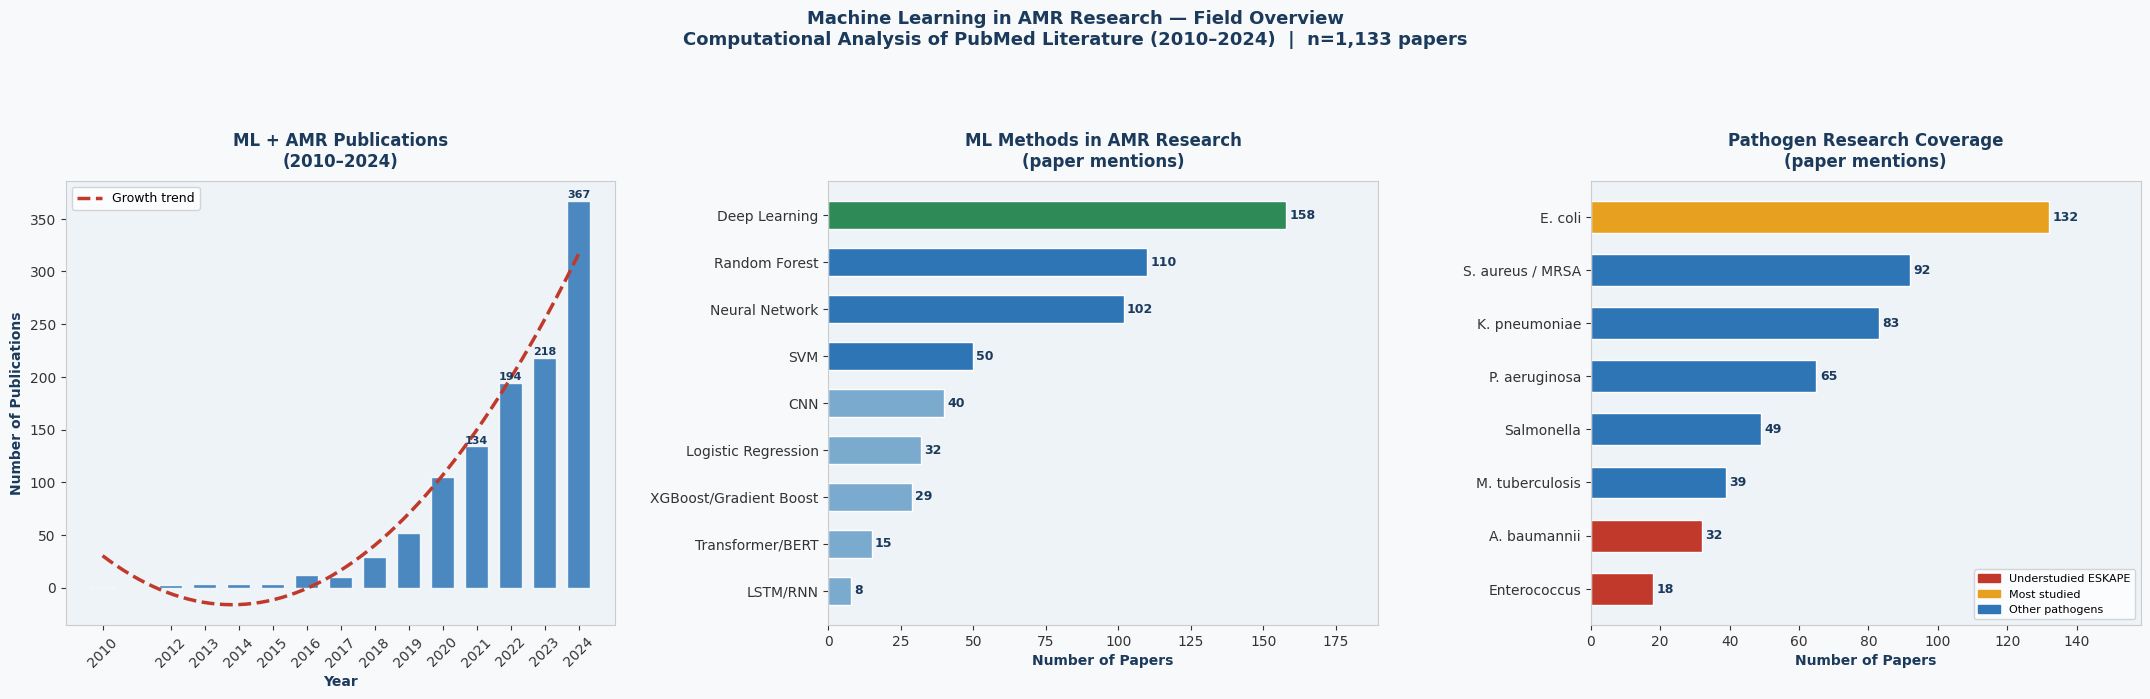

Figure 1 saved


In [ ]:
# _________________________________________________________
# Visualisation
# _________________________________________________________

NAVY   = '#1B3A5C'
ACCENT = '#2E75B6'
GREEN  = '#2E8B57'
RED    = '#C0392B'
LIGHT  = '#EEF3F8'
GOLD   = '#E8A020'

def style_ax(ax, title):
    ax.set_facecolor(LIGHT)
    ax.set_title(title, fontsize=12, fontweight='bold', color=NAVY, pad=10)
    ax.tick_params(colors='#333333')
    for spine in ax.spines.values():
        spine.set_edgecolor('#CCCCCC')

fig1, axes = plt.subplots(1, 3, figsize=(22, 7))
fig1.patch.set_facecolor('#F8F9FA')

# ---------------------------------------------------------
# PLOT 1: Publication growth
# ---------------------------------------------------------
ax1 = axes[0]
yearly = df_papers.groupby('year').size().reset_index(name='count')
yearly = yearly[yearly['year'].between(2010, 2024)]

ax1.bar(yearly['year'], yearly['count'],
        color=ACCENT, edgecolor='white', width=0.7, alpha=0.85)

z = np.polyfit(yearly['year'], yearly['count'], 2)
p = np.poly1d(z)
x_smooth = np.linspace(yearly['year'].min(), yearly['year'].max(), 200)
ax1.plot(x_smooth, p(x_smooth), color=RED, lw=2.5,
         linestyle='--', label='Growth trend')

for _, row in yearly.iterrows():
    if row['count'] > yearly['count'].quantile(0.75):
        ax1.text(row['year'], row['count'] + 3, str(int(row['count'])),
                 ha='center', fontsize=8, fontweight='bold', color=NAVY)

style_ax(ax1, 'ML + AMR Publications\n(2010–2024)')
ax1.set_xlabel('Year', color=NAVY, fontweight='bold')
ax1.set_ylabel('Number of Publications', color=NAVY, fontweight='bold')
ax1.set_xticks(yearly['year'])
ax1.tick_params(axis='x', rotation=45)
ax1.legend(fontsize=9)

# --------------------------------------------------------
# PLOT 2: ML methods
# --------------------------------------------------------
ax2 = axes[1]
ml_cols   = [m for m in ml_methods.keys() if df_papers[m].sum() > 0]
ml_counts = {m: df_papers[m].sum() for m in ml_cols}
ml_sorted = dict(sorted(ml_counts.items(), key=lambda x: x[1]))

bar_colors = [GREEN if v == max(ml_counts.values()) else
              ACCENT if v >= np.percentile(list(ml_counts.values()), 60)
              else '#7AABCF'
              for v in ml_sorted.values()]

bars2 = ax2.barh(list(ml_sorted.keys()), list(ml_sorted.values()),
                  color=bar_colors, edgecolor='white', height=0.6)
for bar in bars2:
    ax2.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             str(int(bar.get_width())),
             va='center', fontsize=9, color=NAVY, fontweight='bold')

style_ax(ax2, 'ML Methods in AMR Research\n(paper mentions)')
ax2.set_xlabel('Number of Papers', color=NAVY, fontweight='bold')
ax2.set_xlim([0, max(ml_counts.values()) * 1.2])

# --------------------------------------------------------
# PLOT 3: Pathogen coverage
# --------------------------------------------------------
ax3 = axes[2]
path_counts = {p: df_papers[p].sum() for p in pathogens.keys()}
path_sorted = dict(sorted(path_counts.items(), key=lambda x: x[1]))

path_colors = [RED if k in ['A. baumannii', 'Enterococcus'] else
               GOLD if k == 'E. coli' else ACCENT
               for k in path_sorted.keys()]

bars3 = ax3.barh(list(path_sorted.keys()), list(path_sorted.values()),
                  color=path_colors, edgecolor='white', height=0.6)
for bar in bars3:
    ax3.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             str(int(bar.get_width())),
             va='center', fontsize=9, color=NAVY, fontweight='bold')

style_ax(ax3, 'Pathogen Research Coverage\n(paper mentions)')
ax3.set_xlabel('Number of Papers', color=NAVY, fontweight='bold')
ax3.set_xlim([0, max(path_counts.values()) * 1.2])

understudied = mpatches.Patch(color=RED,   label='Understudied ESKAPE')
dominant     = mpatches.Patch(color=GOLD,  label='Most studied')
other        = mpatches.Patch(color=ACCENT, label='Other pathogens')
ax3.legend(handles=[understudied, dominant, other], fontsize=8)

plt.suptitle(
    'Machine Learning in AMR Research — Field Overview\n'
    'Computational Analysis of PubMed Literature (2010–2024)  |  n=1,133 papers',
    fontsize=13, fontweight='bold', color=NAVY, y=1.02
)
plt.tight_layout(pad=2.5)
plt.savefig('AMR_ML_Figure1_Overview.png', dpi=180,
            bbox_inches='tight', facecolor=fig1.get_facecolor())
plt.show()
print("Figure 1 saved")

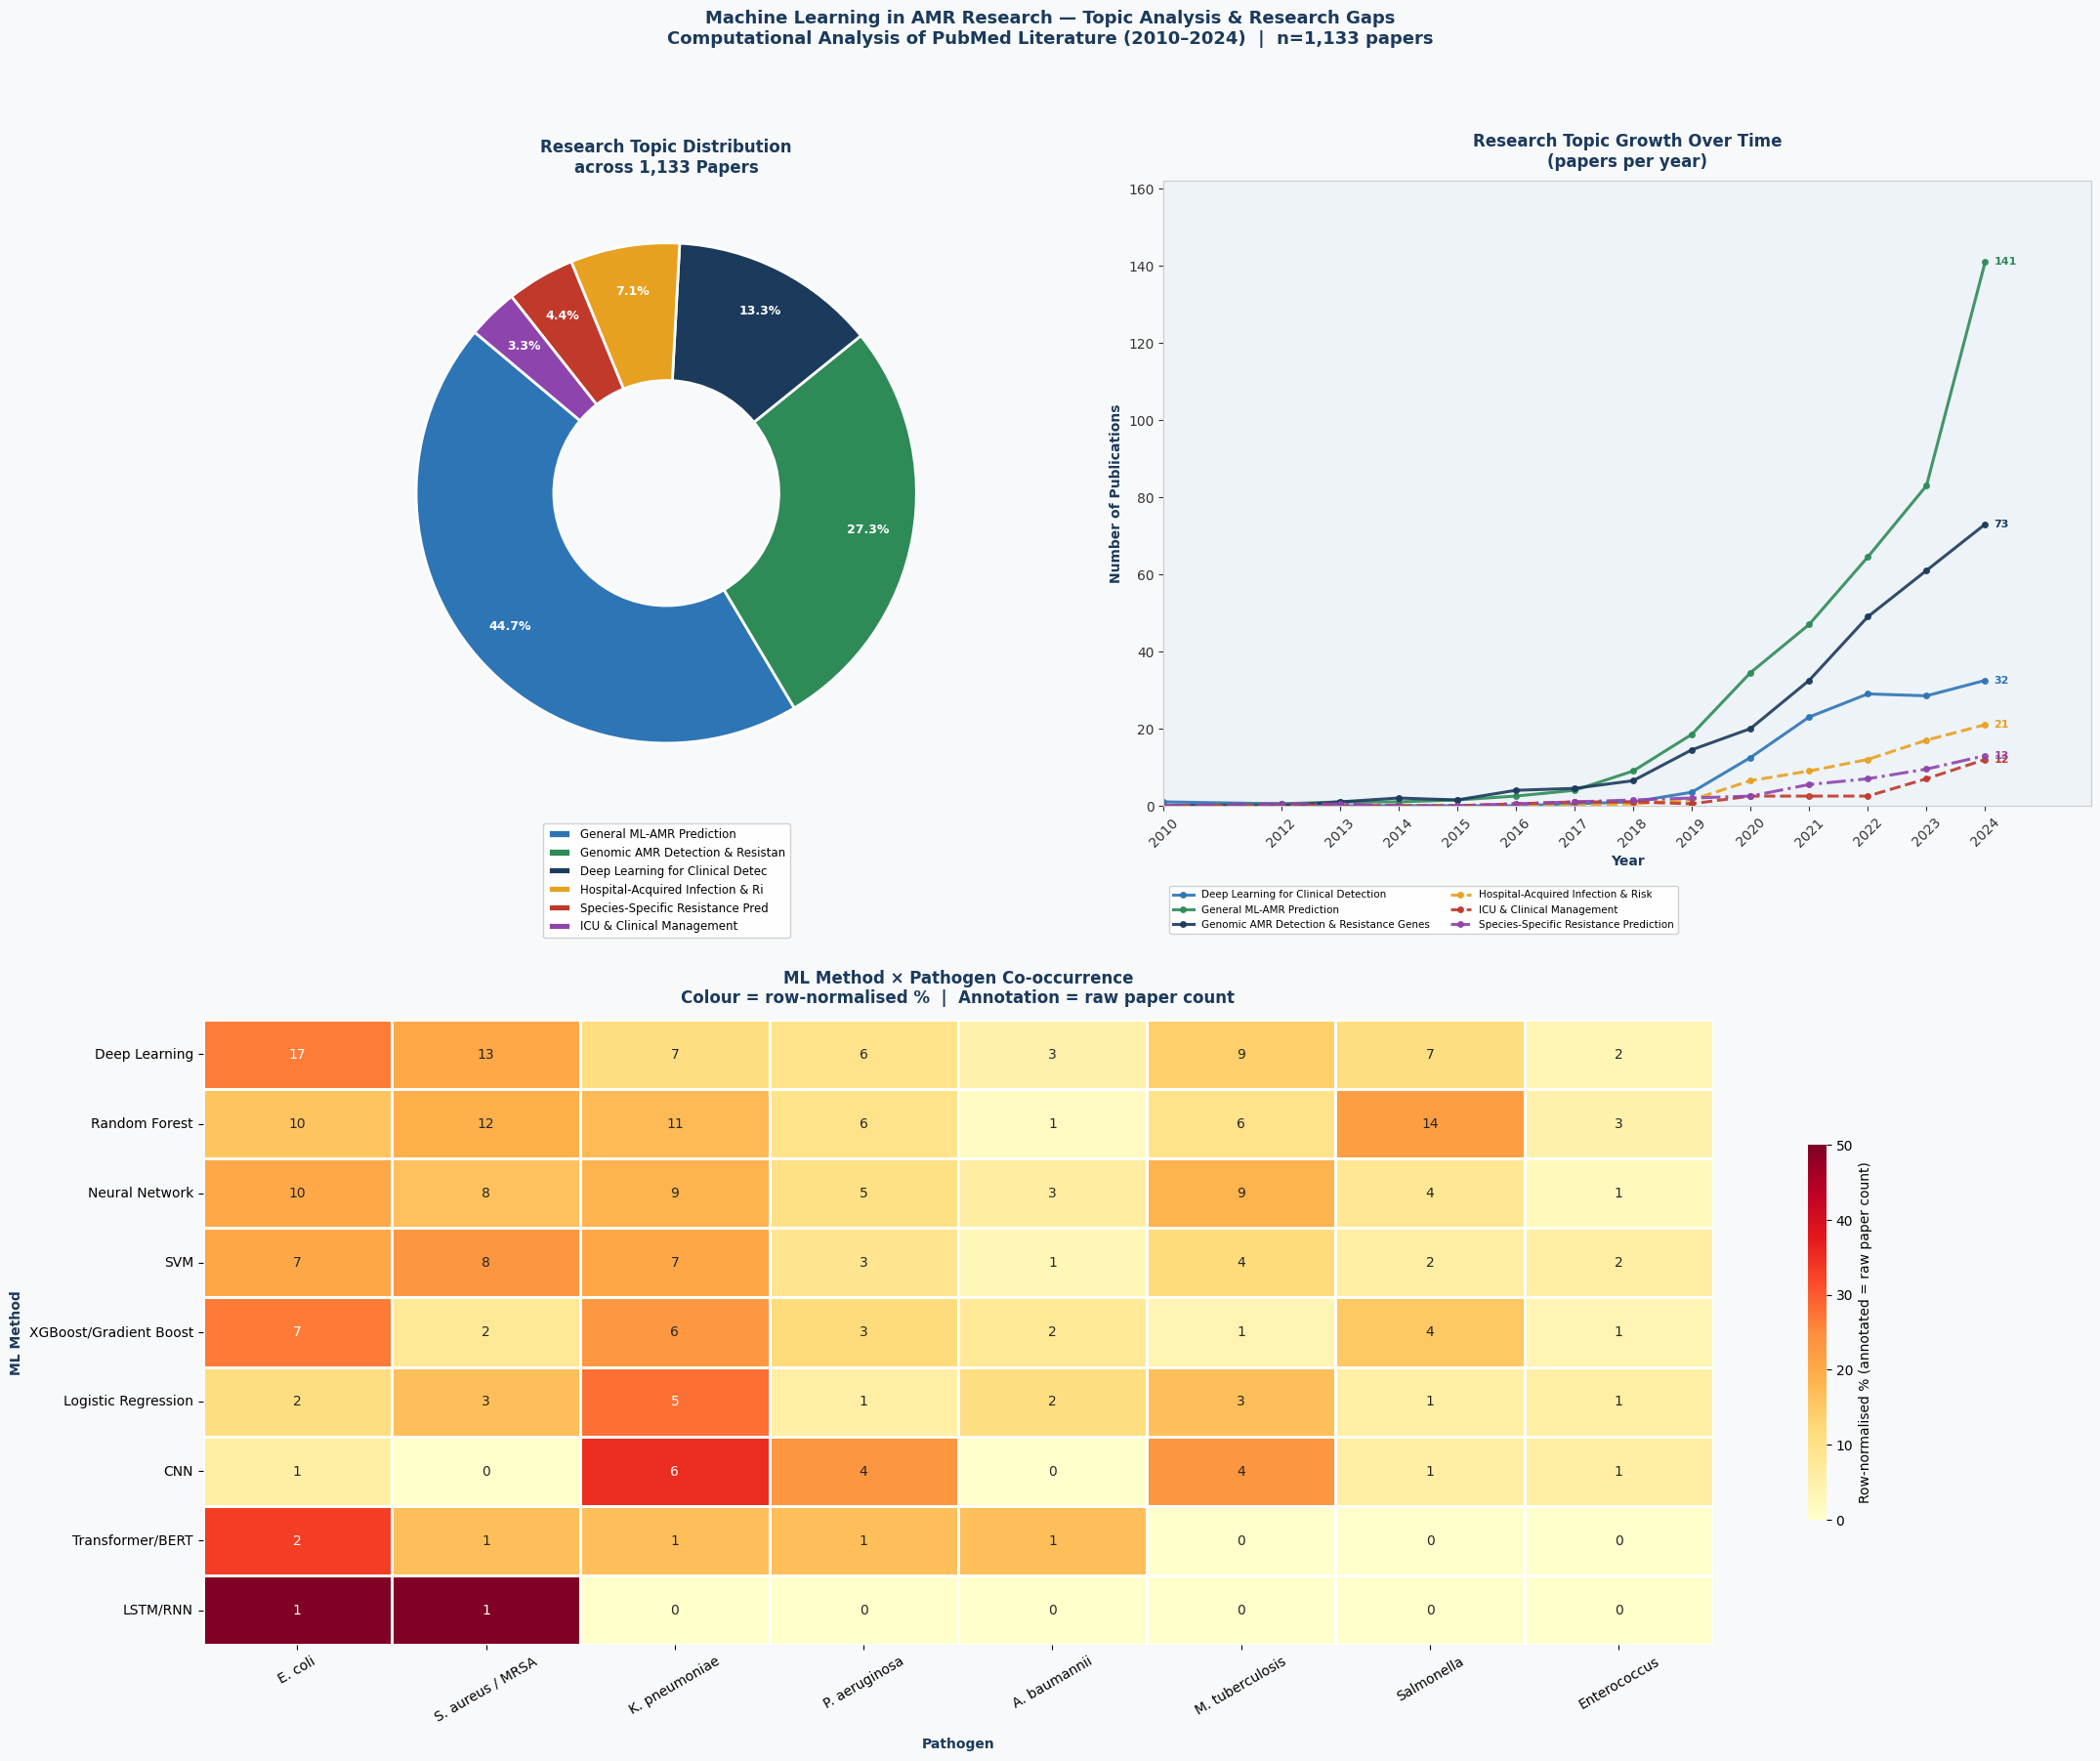

Figure 2 saved


In [ ]:
# _________________________________________________________
# Visualisation-2
# _________________________________________________________

fig2 = plt.figure(figsize=(22, 18))
fig2.patch.set_facecolor('#F8F9FA')

# ---------------------------------------------------------
# PLOT 1: Topic donut
# ---------------------------------------------------------
ax1 = fig2.add_subplot(2, 2, 1)

topic_counts = df_papers['dominant_topic_label'].value_counts()
colors_donut = [ACCENT, GREEN, NAVY, GOLD, RED, '#8E44AD']

wedges, texts, autotexts = ax1.pie(
    topic_counts.values,
    labels=None,
    autopct='%1.1f%%',
    colors=colors_donut,
    startangle=140,
    pctdistance=0.82,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(9)
    at.set_color('white')
    at.set_fontweight('bold')

ax1.legend(wedges, [t[:32] for t in topic_counts.index],
           loc='lower center', bbox_to_anchor=(0.5, -0.22),
           fontsize=8.5, framealpha=0.9, ncol=1)
ax1.set_title('Research Topic Distribution\nacross 1,133 Papers',
              fontsize=12, fontweight='bold', color=NAVY)

# --------------------------------------------------------
# PLOT 2: Topic growth over time
# --------------------------------------------------------
ax2 = fig2.add_subplot(2, 2, 2)

topic_year = (df_papers.groupby(['year', 'dominant_topic_label'])
                        .size()
                        .unstack(fill_value=0))
topic_year = topic_year[topic_year.index.astype(int).isin(range(2010, 2025))]
topic_year.index = topic_year.index.astype(int)
topic_year_smooth = topic_year.rolling(window=2, min_periods=1).mean()

line_colors = [ACCENT, GREEN, NAVY, GOLD, RED, '#8E44AD']
line_styles = ['-', '-', '-', '--', '--', '-.']

for i, col in enumerate(topic_year_smooth.columns):
    ax2.plot(topic_year_smooth.index,
             topic_year_smooth[col],
             color=line_colors[i],
             linestyle=line_styles[i],
             linewidth=2.2,
             marker='o', markersize=4,
             label=col, alpha=0.9)
    last_val = topic_year_smooth[col].iloc[-1]
    ax2.text(2024.15, last_val, f'{int(last_val)}',
             va='center', fontsize=8,
             color=line_colors[i], fontweight='bold')

style_ax(ax2, 'Research Topic Growth Over Time\n(papers per year)')
ax2.set_xlabel('Year', color=NAVY, fontweight='bold')
ax2.set_ylabel('Number of Publications', color=NAVY, fontweight='bold')
ax2.set_xticks(list(topic_year_smooth.index))
ax2.tick_params(axis='x', rotation=45)
ax2.legend(loc='upper left', fontsize=7.5, framealpha=0.9,
           bbox_to_anchor=(0.0, -0.12), ncol=2)
ax2.set_xlim([2010, 2025.8])
ax2.set_ylim([0, topic_year_smooth.values.max() * 1.15])

# --------------------------------------------------------
# PLOT 3: ML X Pathogen heatmap
# --------------------------------------------------------
ax3 = fig2.add_subplot(2, 1, 2)

ml_cols   = [m for m in ml_methods.keys() if df_papers[m].sum() > 0]
path_cols = list(pathogens.keys())

# Building co-occurrence matrix
heatmap_data = pd.DataFrame(index=ml_cols, columns=path_cols, dtype=float)

for ml in ml_cols:
    for path in path_cols:
        heatmap_data.loc[ml, path] = ((df_papers[ml] == 1) & (df_papers[path] == 1)).sum()

# Sorting by total mentions for cleaner layout
heatmap_data['total'] = heatmap_data.sum(axis=1)
heatmap_data = heatmap_data.sort_values('total', ascending=False).drop('total', axis=1)

# Normalise by ML method
heatmap_pct = heatmap_data.div(heatmap_data.sum(axis=1), axis=0) * 100

sns.heatmap(
    heatmap_pct,
    ax=ax3,
    cmap='YlOrRd',
    annot=heatmap_data.values,   # show raw counts as annotations
    fmt='.0f',
    linewidths=0.8,
    linecolor='white',
    cbar_kws={'label': 'Row-normalised % (annotated = raw paper count)',
              'shrink': 0.6},
    vmin=0, vmax=50
)

ax3.set_title(
    'ML Method × Pathogen Co-occurrence\n'
    'Colour = row-normalised %  |  Annotation = raw paper count',
    fontsize=12, fontweight='bold', color=NAVY, pad=12
)
ax3.set_xlabel('Pathogen', color=NAVY, fontweight='bold', labelpad=10)
ax3.set_ylabel('ML Method', color=NAVY, fontweight='bold')
ax3.tick_params(axis='x', rotation=30, labelsize=10)
ax3.tick_params(axis='y', rotation=0,  labelsize=10)

plt.suptitle(
    'Machine Learning in AMR Research — Topic Analysis & Research Gaps\n'
    'Computational Analysis of PubMed Literature (2010–2024)  |  n=1,133 papers',
    fontsize=13, fontweight='bold', color=NAVY, y=1.01
)
plt.tight_layout(pad=2.5)
plt.savefig('AMR_ML_Figure2_Analysis.png', dpi=180,
            bbox_inches='tight', facecolor=fig2.get_facecolor())
plt.show()
print("Figure 2 saved")